In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Layer, Embedding, Dense, LayerNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
import string

In [ ]:
df_passages = pd.read_parquet("hf://datasets/rag-datasets/rag-mini-bioasq/data/passages.parquet/part.0.parquet")
df_test = pd.read_parquet("hf://datasets/rag-datasets/rag-mini-bioasq/data/test.parquet/part.0.parquet")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
df_passages.head()

,passage
id,
9797,New data on viruses isolated from patients wit...
11906,We describe an improved method for detecting d...
16083,We have studied the effects of curare on respo...
23188,Kinetic and electrophoretic properties of 230-...
23469,Male Wistar specific-pathogen-free rats aged 2...


In [ ]:
df_test.head()

,question,answer,relevant_passage_ids
id,,,
0,Is Hirschsprung disease a mendelian or a multi...,"Coding sequence mutations in RET, GDNF, EDNRB,...","[20598273, 6650562, 15829955, 15617541, 230011..."
1,List signaling molecules (ligands) that intera...,The 7 known EGFR ligands are: epidermal growt...,"[23821377, 24323361, 23382875, 22247333, 23787..."
2,Is the protein Papilin secreted?,"Yes, papilin is a secreted protein","[21784067, 19297413, 15094122, 7515725, 332004..."
3,Are long non coding RNAs spliced?,Long non coding RNAs appear to be spliced thro...,"[22955974, 21622663, 22707570, 22955988, 24285..."
4,Is RANKL secreted from the cells?,Receptor activator of nuclear factor κB ligand...,"[22867712, 23827649, 21618594, 23835909, 24265..."


In [ ]:
passage_dict = pd.Series(df_passages['passage'].values, index=df_passages.index).to_dict()

In [ ]:
def map_passages(id_list):
    if isinstance(id_list, list):
        return " ".join(passage_dict.get(pid, "") for pid in id_list)
    return ""


In [ ]:
df_test['relevant_passages_text'] = df_test['relevant_passage_ids'].apply(map_passages)

In [ ]:
# 3. Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df_test['question_clean'] = df_test['question'].astype(str).apply(clean_text)
df_test['relevant_passages_clean'] = df_test['relevant_passages_text'].astype(str).apply(clean_text)

In [ ]:
# Combine all text to fit tokenizer
texts = df_test['question_clean'].tolist() + df_test['relevant_passages_clean'].tolist()


In [ ]:
# 4. Tokenizer and sequences
max_vocab = 20000
max_len = 128

tokenizer = Tokenizer(num_words=max_vocab, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
word_index = tokenizer.word_index
vocab_size = min(max_vocab, len(word_index)) + 1


In [ ]:
# Convert texts to padded sequences
question_seqs = tokenizer.texts_to_sequences(df_test['question_clean'])
passage_seqs = tokenizer.texts_to_sequences(df_test['relevant_passages_clean'])

question_padded = pad_sequences(question_seqs, maxlen=max_len, padding='post')
passage_padded = pad_sequences(passage_seqs, maxlen=max_len, padding='post')


In [ ]:
print(f"Vocab size: {vocab_size}")


Vocab size: 7211


In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2025-07-23 14:43:09--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-07-23 14:43:09--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-07-23 14:43:10--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
# 5. Load GloVe embeddings and build embedding matrix
embedding_dim = 100
embedding_index = {}

glove_path = 'glove.6B.100d.txt'  # Make sure this file is present

with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.strip().split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in word_index.items():
    if i >= vocab_size:
        continue
    vec = embedding_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec

In [ ]:
# 6. Define Relative Positional Encoding Layer
class RelativePositionalEncoding(Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.max_len = max_len
        self.d_model = d_model
        self.rel_pos_emb = Embedding(input_dim=2*max_len - 1, output_dim=d_model)

    def call(self, seq_len):
        range_vec = tf.range(seq_len)
        rel_pos = range_vec[None, :] - range_vec[:, None] + self.max_len - 1
        return self.rel_pos_emb(rel_pos)

In [ ]:
# 7. Transformer Encoder Layer
class TransformerEncoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, max_len):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads

        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])

        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(0.1)
        self.dropout2 = tf.keras.layers.Dropout(0.1)

        self.rel_pos_encoding = RelativePositionalEncoding(max_len, d_model)
        self.max_len = max_len

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]

        rel_pos_emb = self.rel_pos_encoding(seq_len)  # (seq_len, seq_len, d_model)

        attn_output = self.mha(query=x, key=x, value=x, training=training)

        # Approximate integration of relative positional embeddings by adding mean vector per position
        rel_pos_mean = tf.reduce_mean(rel_pos_emb, axis=1)  # (seq_len, d_model)
        attn_output += rel_pos_mean[None, :, :]

        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.norm2(out1 + ffn_output)

        return out2

In [ ]:
# 8. Build Model
d_model = embedding_dim
num_heads = 4
dff = 256

inputs = Input(shape=(max_len,))
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(inputs)

transformer_encoder = TransformerEncoderLayer(d_model, num_heads, dff, max_len)(embedding_layer)

model = Model(inputs=inputs, outputs=transformer_encoder)
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 128, 100)       │       721,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer       │ (None, 128, 100)       │       238,756 │
│ (TransformerEncoderLayer)       │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 959,856 (3.66 MB)

 Trainable params: 238,756 (932.64 KB)

 Non-trainable params: 721,100 (2.75 MB)

In [ ]:
# 9. Run a test forward pass on question sequences
# ---------------------------
output = model(question_padded[:5])
print("Output shape:", output.shape)

Output shape: (5, 128, 100)


### Part 2

In [ ]:
# Decoder to project transformer output back to vocabulary space
output_layer = Dense(vocab_size, activation='softmax')(transformer_encoder)

final_model = Model(inputs=inputs, outputs=output_layer)
final_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 128, 100)       │       721,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer       │ (None, 128, 100)       │       238,756 │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128, 7211)      │       728,311 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,688,167 (6.44 MB)

 Trainable params: 967,067 (3.69 MB)

 Non-trainable params: 721,100 (2.75 MB)

In [ ]:
final_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Shift targets: typical in sequence modeling (teacher forcing)
# We’ll use passage text as input and question text as target
X = passage_padded
y = question_padded

# Expand dimensions for sparse_categorical_crossentropy
y = np.expand_dims(y, -1)

In [ ]:
final_model.fit(X, y, epochs=3, batch_size=16, validation_split=0.1)

Epoch 1/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9116 - loss: 2.5945 - val_accuracy: 0.9403 - val_loss: 0.4562
Epoch 2/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9366 - loss: 0.4736 - val_accuracy: 0.9436 - val_loss: 0.4497
Epoch 3/3
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9378 - loss: 0.4607 - val_accuracy: 0.9455 - val_loss: 0.4461


In [ ]:
!pip install evaluate rouge_score bert_score --quiet

In [ ]:
import evaluate

rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

# Generate predictions (argmax for simplicity)
y_pred = final_model.predict(X[:200])
y_pred_ids = np.argmax(y_pred, axis=-1)

# Convert back to text
inv_word_index = {v: k for k, v in tokenizer.word_index.items()}
inv_word_index[0] = ''  # padding

def decode_sequence(seq):
    return ' '.join([inv_word_index.get(i, '') for i in seq if i != 0])

pred_texts = [decode_sequence(seq) for seq in y_pred_ids]
true_texts = [decode_sequence(seq) for seq in question_padded[:200]]

# Evaluate
rouge_result = rouge.compute(predictions=pred_texts, references=true_texts, use_stemmer=True)
bert_result = bertscore.compute(predictions=pred_texts, references=true_texts, lang='en')

print("ROUGE-L:", rouge_result['rougeL'])
print("BERT-F1:", np.mean(bert_result['f1']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ROUGE-L: 0.23995719594016793
BERT-F1: 0.8043225535750389


In [ ]:
print("Evaluation Summary")
print(f"ROUGE-L Score: {rouge_result['rougeL']:.4f}")
print(f"BERT-F1 Score: {np.mean(bert_result['f1']):.4f}")
print("Model: Custom Transformer Encoder with GloVe + Relative Positional Encoding")
print("Recommendation: Add decoder layer or use Seq2Seq encoder-decoder for better question generation")


Evaluation Summary
ROUGE-L Score: 0.2400
BERT-F1 Score: 0.8043
Model: Custom Transformer Encoder with GloVe + Relative Positional Encoding
Recommendation: Add decoder layer or use Seq2Seq encoder-decoder for better question generation


In [ ]:
sample_input = tf.convert_to_tensor(question_padded[:1])
sample_output = model(sample_input)

print("Attention output (sample):", sample_output.shape)

Attention output (sample): (1, 128, 100)


In [ ]:
class TransformerEncoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, max_len):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads

        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model, output_shape=None)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])

        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(0.1)
        self.dropout2 = tf.keras.layers.Dropout(0.1)

        self.rel_pos_encoding = RelativePositionalEncoding(max_len, d_model)
        self.max_len = max_len

    def call(self, x, training=False, return_attention=False):
        seq_len = tf.shape(x)[1]
        rel_pos_emb = self.rel_pos_encoding(seq_len)

        attn_output, attn_weights = self.mha(query=x, key=x, value=x, return_attention_scores=True, training=training)
        rel_pos_mean = tf.reduce_mean(rel_pos_emb, axis=1)
        attn_output += rel_pos_mean[None, :, :]

        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.norm2(out1 + ffn_output)

        if return_attention:
            return out2, attn_weights
        else:
            return out2

In [ ]:
# Rebuild the layer separately
test_encoder_layer = TransformerEncoderLayer(d_model, num_heads, dff, max_len)

# Run a forward pass with attention output
sample_input = tf.convert_to_tensor(question_padded[:1])
embedding_sample = Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False)(sample_input)

encoded_output, attention_weights = test_encoder_layer(embedding_sample, return_attention=True)

print("Attention shape:", attention_weights.shape)  # (batch, num_heads, seq_len, seq_len)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Attention shape: (1, 4, 128, 128)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


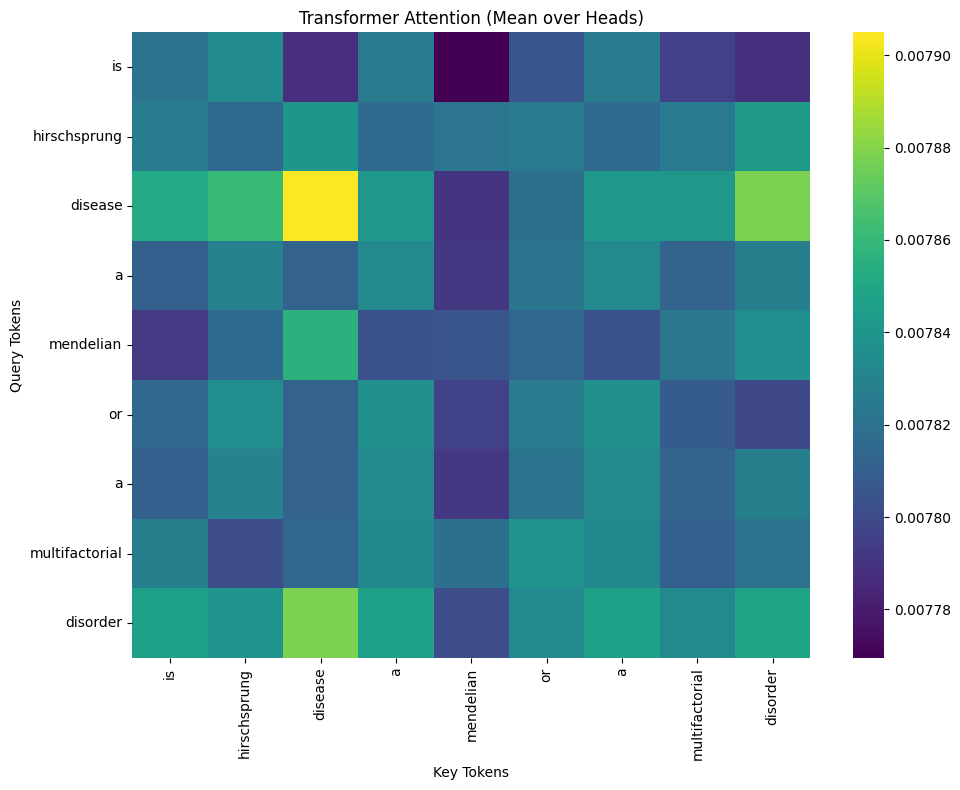

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select a sample input and convert to tensor
sample_index = 0
sample_seq = question_padded[sample_index:sample_index+1]
sample_tensor = tf.convert_to_tensor(sample_seq)

# Rebuild embedding and encoder layer
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)

embedded_input = embedding_layer(sample_tensor)

# Run forward pass with attention
test_encoder = TransformerEncoderLayer(d_model, num_heads, dff, max_len)
encoded_out, attention_weights = test_encoder(embedded_input, return_attention=True)

# Convert attention to NumPy
attention = attention_weights[0].numpy()  # (heads, seq_len, seq_len)

# Limit to actual token length (remove padding)
actual_len = np.count_nonzero(sample_seq)
attention = attention[:, :actual_len, :actual_len]

# Decode token labels
inv_word_index = {v: k for k, v in tokenizer.word_index.items()}
inv_word_index[0] = "<PAD>"

tokens = [inv_word_index.get(i, '') for i in sample_seq[0][:actual_len]]

#Plot mean attention over heads
mean_attention = attention.mean(axis=0)  # (seq_len, seq_len)

plt.figure(figsize=(10, 8))
sns.heatmap(mean_attention, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
plt.title("Transformer Attention (Mean over Heads)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()